In [25]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error

from agents import SmartHouseholdAgent
from utils import set_seed, asymmetric_profit_loss,create_sequences
set_seed(42)

Сид установлен на 42 для Python, NumPy, TensorFlow и PYTHONHASHSEED.


# Подготовка тестовых данных

In [26]:

def get_season(month):
    if month in [12, 1, 2]: return 'winter'
    elif month in [3, 4, 5]: return 'spring'
    elif month in [6, 7, 8]: return 'summer'
    else: return 'autumn'
    
def get_holiday_type_2025(timestamp):
    month, day, weekday = timestamp.month, timestamp.day, timestamp.weekday()
    if month == 12 and day == 31: return 'new_year_eve'
    if month == 1 and day == 1: return 'new_year_morning'
    if month == 1 and day == 2: return 'holiday_day_1_2'
    if month == 1 and day in [3, 4, 5, 6, 7, 8]: return 'holiday_day_3_8'
    if month == 5 and day in [1, 2, 3, 4]: return 'may_holiday_1_4'
    if month == 5 and day in [5, 6, 7]: return 'may_working_week'
    if month == 5 and day in [8, 9, 10, 11]: return 'may_holiday_8_11'
    if (month == 2 and day == 23) or (month == 3 and day == 8) or \
       (month == 6 and day == 12) or (month == 11 and day == 4): return 'other_holiday'
    if (month == 2 and day == 22) or (month == 3 and day == 7) or \
       (month == 4 and day == 30) or (month == 5 and day == 7) or \
       (month == 6 and day == 11) or (month == 11 and day == 3): return 'shortened_day'
    if weekday >= 5: return 'weekend'
    return 'weekday'

def get_dynamic_price_fixed(hour, total_grid_load_watts):
    base_price = 6.0 
    time_factor = 1.6 if 7 <= hour <= 22 else 0.4
    load_mw = total_grid_load_watts / 1_000_000.0
    load_factor = 1.0 + (load_mw / 50.0) * 0.01 
    return base_price * time_factor * load_factor

def run_simulation_fixed(model_name, prediction_matrix, agents_list, dates_array, days=30):
    for agent in agents_list: agent.reset()
        
    hours_to_sim = days * 24
    GRID_SCALE = 141.0 
    history = []
    
    for step in range(hours_to_sim):
        if step >= len(dates_array): break
            
        current_sim_time = pd.to_datetime(dates_array[step])
        hour = current_sim_time.hour
        day_type = get_holiday_type_2025(current_sim_time)
        season = get_season(current_sim_time.month)
        
        load_forecast_watts = prediction_matrix[step].flatten()
        
        price_forecast_rub = []
        for h in range(len(load_forecast_watts)):
            f_time = current_sim_time + timedelta(hours=h)
            watts = float(load_forecast_watts[h]) 
            f_price = get_dynamic_price_fixed(f_time.hour, watts * GRID_SCALE)
            price_forecast_rub.append(f_price)
            
        price_forecast_rub = np.array(price_forecast_rub).flatten()

        base_load_total = sum(agent.measure_consumption(hour, day_type, season) for agent in agents_list)
        base_price = get_dynamic_price_fixed(hour, base_load_total)
        
        smart_load_total = 0
        for agent in agents_list:
            load = agent.optimize_step(hour, day_type, season, price_forecast_rub, real_price_now=base_price)
            smart_load_total += load
            
        smart_price = get_dynamic_price_fixed(hour, smart_load_total)
        
        history.append({
            'timestamp': current_sim_time,
            'base_load': base_load_total,
            'smart_load': smart_load_total,
            'base_price': base_price,
            'smart_price': smart_price,
            'cost_base': (base_load_total / 1000) * base_price,
            'cost_smart': (smart_load_total / 1000) * smart_price
        })
        
    return pd.DataFrame(history)

In [27]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import tensorflow as tf

from agents import SmartHouseholdAgent 
from utils import set_seed, asymmetric_profit_loss, create_sequences

import math
from matplotlib.patches import Patch

set_seed(42)

Сид установлен на 42 для Python, NumPy, TensorFlow и PYTHONHASHSEED.


# Загрузка данных

In [28]:
df_features = pd.read_csv('data/features.csv')
feature_cols = [col for col in df_features.columns if col not in ['timestamp', 'consumption']]

split_idx = int(len(df_features) * 0.8)
test_df = df_features.iloc[split_idx:].copy()

test_X_raw = test_df[feature_cols].values
test_y_raw = test_df['consumption'].values
test_dates = pd.to_datetime(test_df['timestamp']).values

SEQ_LEN = 24
HORIZON = 24


X_test_dl, _, dates_test = create_sequences(test_X_raw, test_y_raw, test_dates, SEQ_LEN, HORIZON)

scaler = joblib.load('model_weights/scaler_gru.joblib')
X_test_dl_scaled = scaler.transform(X_test_dl.reshape(-1, X_test_dl.shape[2])).reshape(X_test_dl.shape)

classic_start_idx = SEQ_LEN
classic_end_idx = len(test_X_raw) - HORIZON + 1
X_test_classic = test_X_raw[classic_start_idx : classic_end_idx]



# Загрузка весов

In [29]:

models_predictions = {}
weights_dir = 'model_weights'


# Classic ML + Optuna
classic_models = {
    'CatBoost (Base)': 'catboost_base.joblib',
    'XGBoost (Base)': 'xgb_base.joblib',
    'Random Forest (Base)': 'rf_base.joblib',
    'CatBoost (Optuna)': 'catboost_optuna.joblib',
    'XGBoost (Optuna)': 'xgb_optuna.joblib',
    'Random Forest (Optuna)': 'rf_optuna.joblib'
}

for name, filename in classic_models.items():
    filepath = os.path.join(weights_dir, filename)
    if os.path.exists(filepath):
        print(f" Загружен классический ML: {name}")
        model = joblib.load(filepath)
        models_predictions[name] = model.predict(X_test_classic)
    else:
        print(f" Пропущен: {name} (файл {filename} не найден)")

# DL
dl_models = {
    'GRU (Custom Loss)': 'gru_model.keras',
    'LSTM (Custom Loss)': 'lstm_model.keras',
    'Hybrid (CNN+LSTM+ATTENTION)': 'hybrid_model.keras'
}

for name, filename in dl_models.items():
    filepath = os.path.join(weights_dir, filename)
    if os.path.exists(filepath):
        print(f"Загружена нейросеть: {name}")
        model = tf.keras.models.load_model(filepath, custom_objects={'asymmetric_profit_loss': asymmetric_profit_loss})
        pred_log = model.predict(X_test_dl_scaled, verbose=0)
        models_predictions[name] = np.expm1(pred_log)
    else:
        print(f" Пропущена: {name} (файл {filename} не найден)")

print(f" Итого загружено моделей для симуляции: {len(models_predictions)}")

 Загружен классический ML: CatBoost (Base)
 Загружен классический ML: XGBoost (Base)
 Загружен классический ML: Random Forest (Base)
 Загружен классический ML: CatBoost (Optuna)
 Загружен классический ML: XGBoost (Optuna)
 Загружен классический ML: Random Forest (Optuna)
Загружена нейросеть: GRU (Custom Loss)
Загружена нейросеть: LSTM (Custom Loss)
Загружена нейросеть: Hybrid (CNN+LSTM+ATTENTION)
 Итого загружено моделей для симуляции: 9


# Симуляция

In [30]:

def get_season(month):
    if month in [12, 1, 2]: return 'winter'
    elif month in [3, 4, 5]: return 'spring'
    elif month in [6, 7, 8]: return 'summer'
    else: return 'autumn'
    
def get_holiday_type_2025(timestamp):
    month, day, weekday = timestamp.month, timestamp.day, timestamp.weekday()
    if month == 12 and day == 31: return 'new_year_eve'
    if month == 1 and day == 1: return 'new_year_morning'
    if month == 1 and day == 2: return 'holiday_day_1_2'
    if month == 1 and day in [3, 4, 5, 6, 7, 8]: return 'holiday_day_3_8'
    if month == 5 and day in [1, 2, 3, 4]: return 'may_holiday_1_4'
    if month == 5 and day in [5, 6, 7]: return 'may_working_week'
    if month == 5 and day in [8, 9, 10, 11]: return 'may_holiday_8_11'
    if (month == 2 and day == 23) or (month == 3 and day == 8) or \
       (month == 6 and day == 12) or (month == 11 and day == 4): return 'other_holiday'
    if (month == 2 and day == 22) or (month == 3 and day == 7) or \
       (month == 4 and day == 30) or (month == 5 and day == 7) or \
       (month == 6 and day == 11) or (month == 11 and day == 3): return 'shortened_day'
    if weekday >= 5: return 'weekend'
    return 'weekday'

def get_dynamic_price_fixed(hour, total_grid_load_watts):
    base_price = 6.0 
    time_factor = 1.6 if 7 <= hour <= 22 else 0.4
    load_mw = total_grid_load_watts / 1_000_000.0
    load_factor = 1.0 + (load_mw / 50.0) * 0.01 
    return base_price * time_factor * load_factor

def run_simulation(model_name, prediction_matrix, agents_list, dates_array, days=30):
    for agent in agents_list: agent.reset()
        
    hours_to_sim = days * 24
    GRID_SCALE = 141.0 
    history = []
    
    for step in range(hours_to_sim):
        if step >= len(dates_array): break
            
        current_sim_time = pd.to_datetime(dates_array[step])
        hour = current_sim_time.hour
        day_type = get_holiday_type_2025(current_sim_time)
        season = get_season(current_sim_time.month)
        
        load_forecast_watts = prediction_matrix[step].flatten()
        
        price_forecast_rub = []
        for h in range(len(load_forecast_watts)):
            f_time = current_sim_time + timedelta(hours=h)
            watts = float(load_forecast_watts[h]) 
            f_price = get_dynamic_price_fixed(f_time.hour, watts * GRID_SCALE)
            price_forecast_rub.append(f_price)
            
        price_forecast_rub = np.array(price_forecast_rub).flatten()

        base_load_total = sum(agent.measure_consumption(hour, day_type, season) for agent in agents_list)
        base_price = get_dynamic_price_fixed(hour, base_load_total)
        
        smart_load_total = 0
        for agent in agents_list:
            load = agent.optimize_step(hour, day_type, season, price_forecast_rub, real_price_now=base_price)
            smart_load_total += load
            
        smart_price = get_dynamic_price_fixed(hour, smart_load_total)
        
        history.append({
            'timestamp': current_sim_time,
            'base_load': base_load_total,
            'smart_load': smart_load_total,
            'base_price': base_price,
            'smart_price': smart_price,
            'cost_base': (base_load_total / 1000) * base_price,
            'cost_smart': (smart_load_total / 1000) * smart_price
        })
        
    return pd.DataFrame(history)

# Сравнение моделей и вывод результатов

In [31]:
GLOBAL_AGENTS = []

for i in range(60): GLOBAL_AGENTS.append(SmartHouseholdAgent(f"res_{i}", 'residential'))
for i in range(80): GLOBAL_AGENTS.append(SmartHouseholdAgent(f"com_{i}", 'commercial'))
for i in range(1):  GLOBAL_AGENTS.append(SmartHouseholdAgent(f"ind_{0}", 'industrial'))

all_sim_results = {}
results_summary = []

print(f"{'Model':<25} | {'Base price':<15} | {'Smart price':<15} | {'Savings'} ")

for name, preds in models_predictions.items():
    df_sim = run_simulation(name, preds, agents_list=GLOBAL_AGENTS, dates_array=dates_test, days=30)
    all_sim_results[name] = df_sim
    
    b_cost = df_sim['cost_base'].sum()
    s_cost = df_sim['cost_smart'].sum()
    profit = b_cost - s_cost
    percent = (profit / b_cost) * 100
    
    results_summary.append({'Model': name, 'Savings (%)': percent, 'Profit': profit})
    b_cost_str = f"{b_cost:,.0f} ₽".replace(',', ' ')
    s_cost_str = f"{s_cost:,.0f} ₽".replace(',', ' ')
    profit_str = f" {profit:,.0f} ₽ ({percent:.2f}%)".replace(',', ' ')
    
    print(f"{name:<25} | {b_cost_str:>15} | {s_cost_str:>15} | {profit_str}")


Model                     | Base price      | Smart price     | Savings 
CatBoost (Base)           |    19 560 176 ₽ |    17 268 262 ₽ |  2 291 914 ₽ (11.72%)
XGBoost (Base)            |    19 569 123 ₽ |    16 579 742 ₽ |  2 989 381 ₽ (15.28%)
Random Forest (Base)      |    19 572 448 ₽ |    17 034 050 ₽ |  2 538 397 ₽ (12.97%)
CatBoost (Optuna)         |    19 550 433 ₽ |    17 104 225 ₽ |  2 446 208 ₽ (12.51%)
XGBoost (Optuna)          |    19 575 014 ₽ |    16 683 056 ₽ |  2 891 958 ₽ (14.77%)
Random Forest (Optuna)    |    19 561 865 ₽ |    17 007 540 ₽ |  2 554 324 ₽ (13.06%)
GRU (Custom Loss)         |    19 567 294 ₽ |    17 119 017 ₽ |  2 448 277 ₽ (12.51%)
LSTM (Custom Loss)        |    19 515 843 ₽ |    16 605 233 ₽ |  2 910 610 ₽ (14.91%)
Hybrid (CNN+LSTM+ATTENTION) |    19 616 085 ₽ |    16 241 309 ₽ |  3 374 776 ₽ (17.20%)


# Визуализация для всех моделей

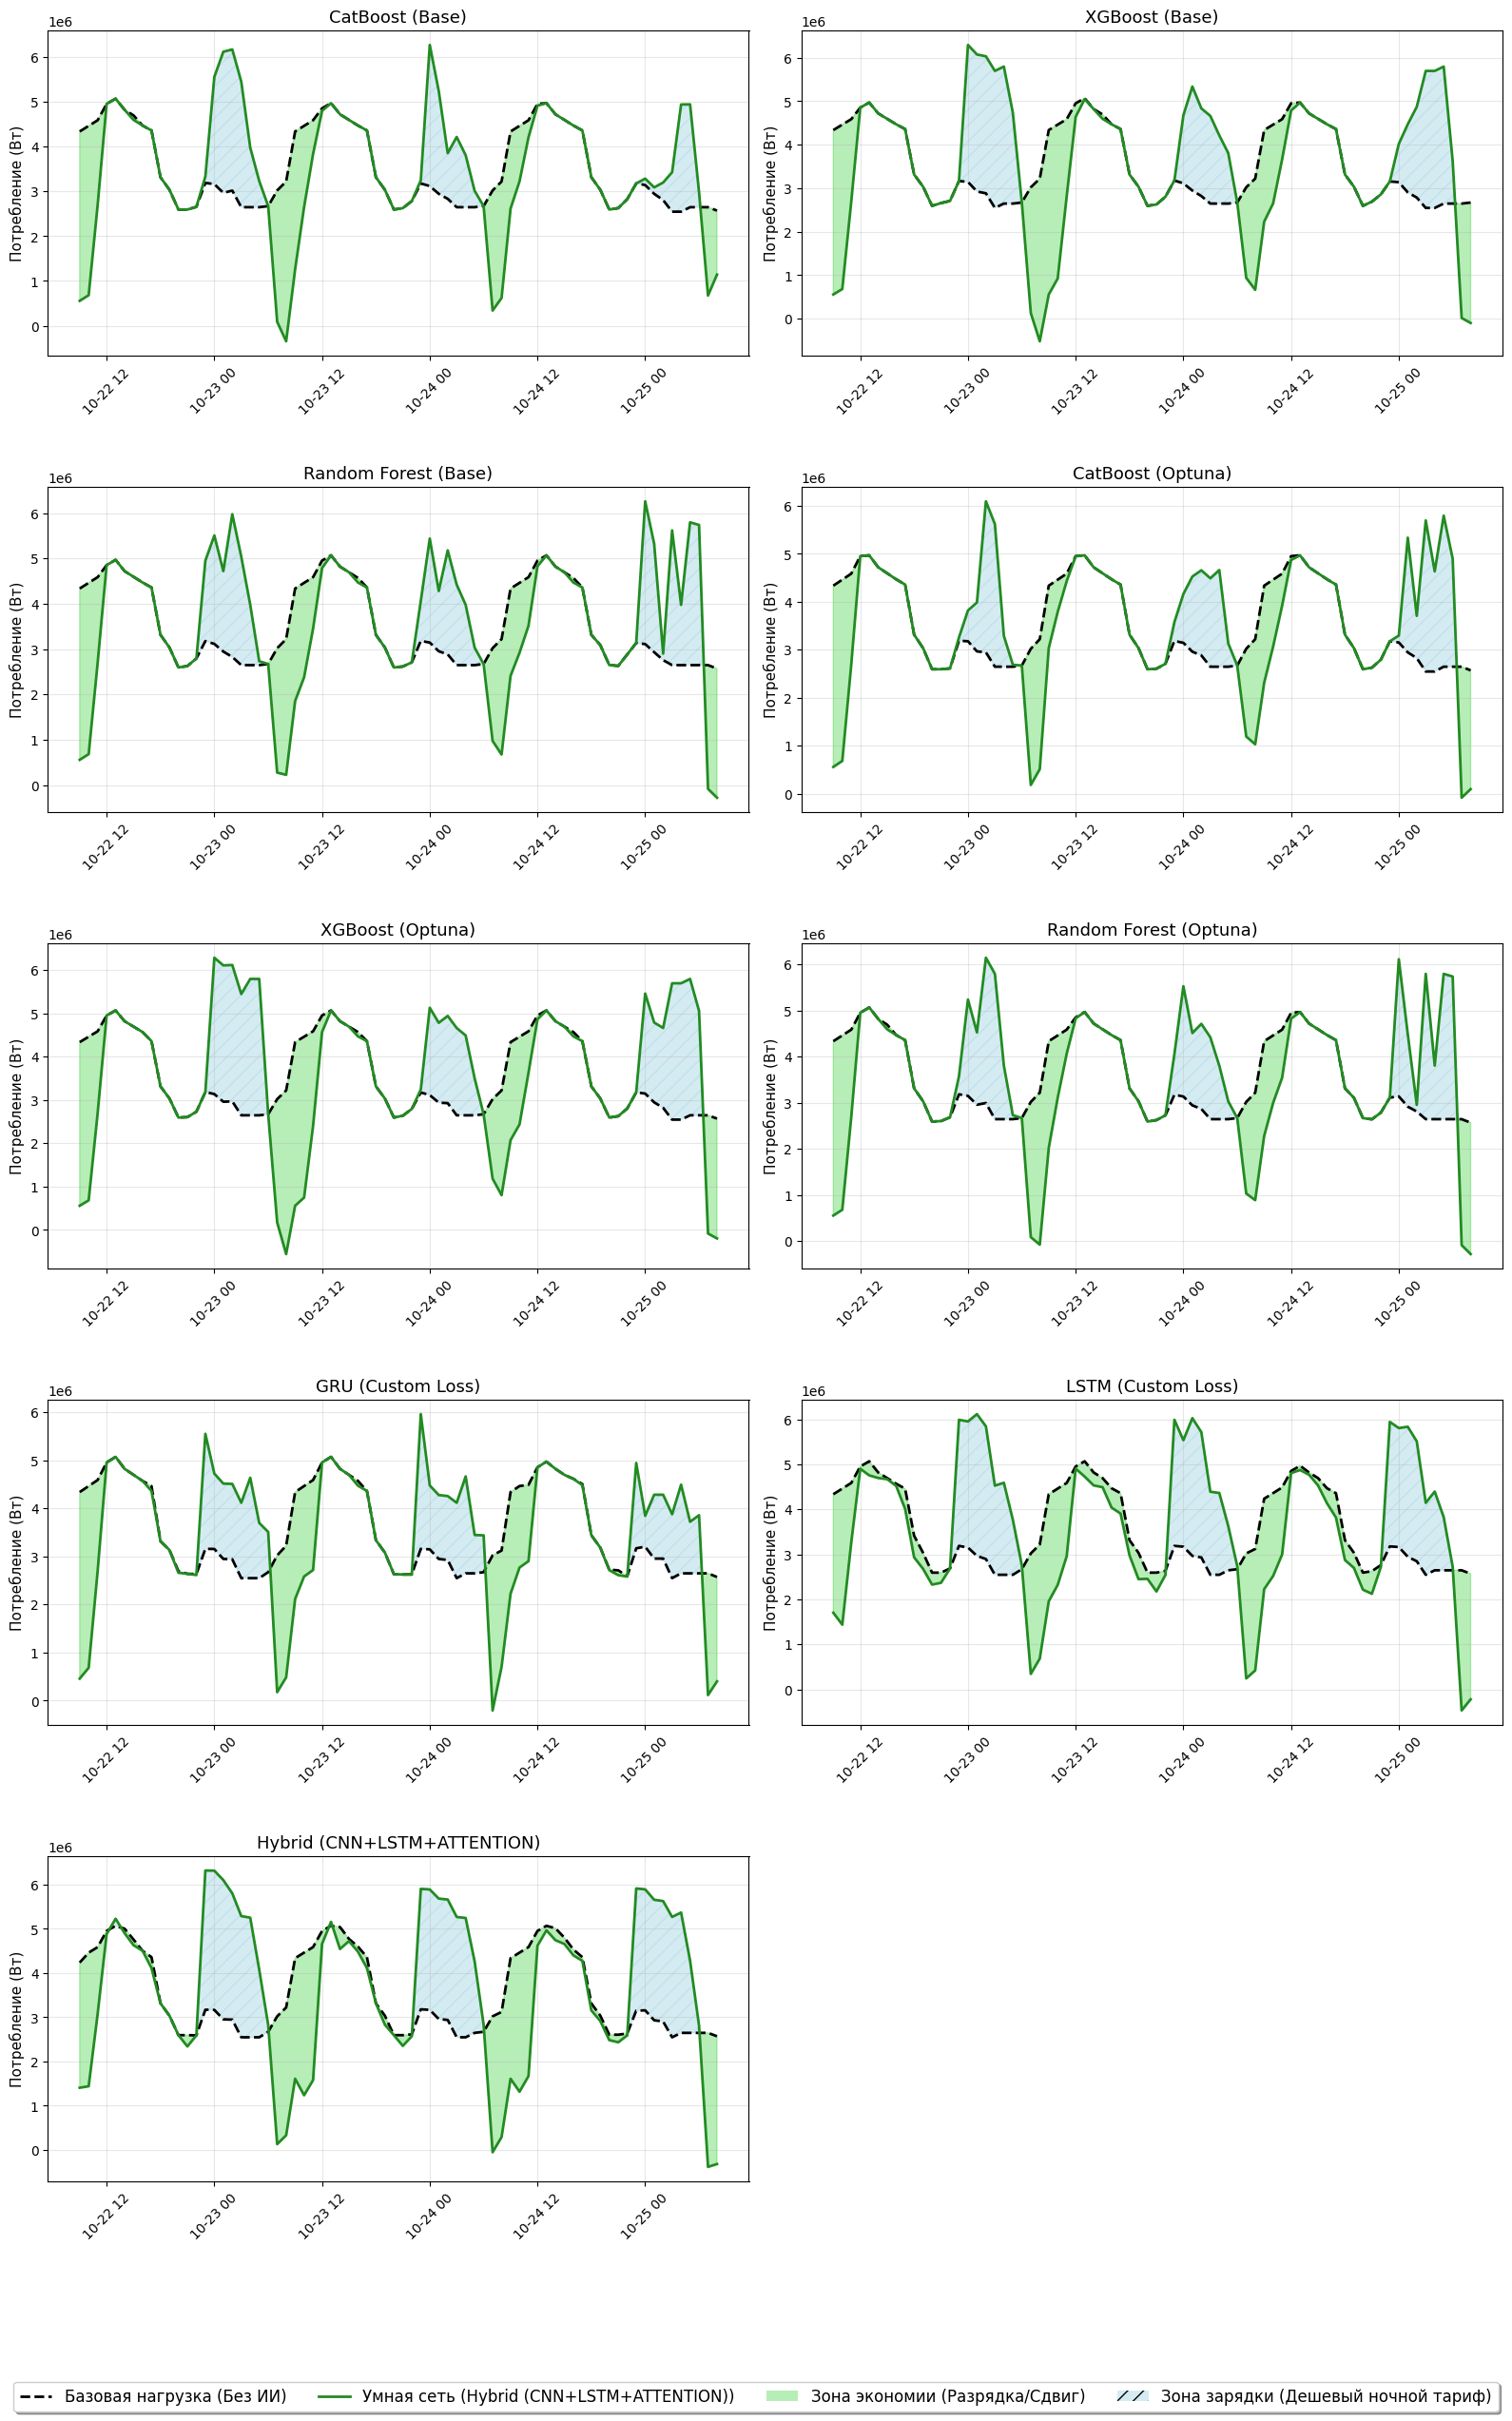

In [32]:
num_models = len(all_sim_results)
num_models = len(all_sim_results)
if num_models > 0:
    cols = 2 if num_models > 1 else 1
    rows = math.ceil(num_models / cols)

    # Создаем фигуру нужного размера в зависимости от количества моделей
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    if num_models > 1:
        axes = axes.flatten()
    else:
        axes = [axes]

    vis_hours = 24 * 3 # Первые 3 дня для графика

    for idx, (model_name, df_sim) in enumerate(all_sim_results.items()):
        ax = axes[idx]
        
        l1, = ax.plot(df_sim['timestamp'][:vis_hours], df_sim['base_load'][:vis_hours], 
                       label='Базовая нагрузка (Без ИИ)', color='black', linestyle='--', linewidth=2)
        l2, = ax.plot(df_sim['timestamp'][:vis_hours], df_sim['smart_load'][:vis_hours], 
                       label=f'Умная сеть ({model_name})', color='forestgreen', linewidth=2)

        # Полная закраска: Зона экономии (Разрядка/Сдвиг нагрузки)
        ax.fill_between(df_sim['timestamp'][:vis_hours], df_sim['base_load'][:vis_hours], df_sim['smart_load'][:vis_hours], 
                         where=(df_sim['smart_load'][:vis_hours] <= df_sim['base_load'][:vis_hours]), 
                         color='limegreen', alpha=0.35, interpolate=True)

        # Полная закраска: Зона потребления (Зарядка батарей ночью)
        ax.fill_between(df_sim['timestamp'][:vis_hours], df_sim['base_load'][:vis_hours], df_sim['smart_load'][:vis_hours], 
                         where=(df_sim['smart_load'][:vis_hours] > df_sim['base_load'][:vis_hours]), 
                         color='lightblue', alpha=0.5, hatch='//', interpolate=True)


        ax.set_title(f"{model_name}", fontsize=13)
            
        ax.set_ylabel('Потребление (Вт)', fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)

    # Удаляем пустые графики, если количество моделей нечетное
    for idx in range(num_models, len(axes)):
        fig.delaxes(axes[idx])

    # Единая легенда для всей фигуры
    patch1 = Patch(facecolor='limegreen', alpha=0.35, label='Зона экономии (Разрядка/Сдвиг)')
    patch2 = Patch(facecolor='lightblue', alpha=0.5, hatch='//', label='Зона зарядки (Дешевый ночной тариф)')
    lines = [l1, l2, patch1, patch2]
    labels = [l.get_label() for l in lines]

    fig.legend(lines, labels, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=12, frameon=True, shadow=True)

    plt.tight_layout()
    # Оставляем место внизу для глобальной легенды
    plt.subplots_adjust(bottom=0.08 if rows > 1 else 0.15, hspace=0.4) 
    plt.savefig('data/16_all_models_simulation.png', dpi=150, bbox_inches='tight')
    plt.show()